# 1. Import and Hardware Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset
import os
import random
import matplotlib.pyplot as plt
import numpy as np
!pip install tqdm -q
from tqdm.auto import tqdm
# Set device to GPU, MPS, or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
DATA_PATH = './data'

# 2. Hyperparameter

In [3]:
BATCH_SIZE = 256
IMG_SIZE = 128
IN_CHANNELS = 3

LR = 1e-4
EPOCHS = 100
SEED = 42
NUM_CLASSES = 50

LATENT_DIM = 512
ENCODER_CHANNELS = [32, 64, 128, 256, 512]

# Weight for the KL divergence term in the VAE loss.
# A higher value encourages a more structured latent space
# but may reduce reconstruction quality.
KL_WEIGHT = 1e-4


# 3. Data Preparation

In [4]:
def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    """Seed function for DataLoader workers to ensure reproducibility."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


In [5]:
train_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ]
)

# Apply seed
set_seed(SEED)
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

filtered_indices = [i for i, label in enumerate(dummy_data._labels) if label < NUM_CLASSES]

train_size = int(0.8 * len(filtered_indices))
val_size = len(filtered_indices) - train_size
split_generator = torch.Generator().manual_seed(SEED)

filtered_dummy_data = Subset(dummy_data, filtered_indices)
train_tmp_subset, val_tmp_subset = random_split(
    filtered_dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = [filtered_indices[i] for i in train_tmp_subset.indices]
val_indices = [filtered_indices[i] for i in val_tmp_subset.indices]

train_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=train_transform,
)

val_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=val_transform,
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)


dummy_test_dataset = datasets.Food101(root=DATA_PATH, split="test", download=True)
test_filterd_indices = [
    i for i, label in enumerate(dummy_test_dataset._labels) if label < NUM_CLASSES
]

test_dataset_full = datasets.Food101(
    root=DATA_PATH,
    split="test",
    download=False,
    transform=val_transform,
)
test_dataset = Subset(test_dataset_full, test_filterd_indices)


In [6]:
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)


# 4. Model Architecture

## VAE Key Differences vs. Standard Autoencoder

1. **Encoder** outputs two vectors: `mu` (mean) and `logvar` (log-variance) instead of a single latent vector.
2. **Reparameterization trick**: `z = mu + std * epsilon` where `epsilon ~ N(0, 1)`. This allows backpropagation through the stochastic sampling.
3. **Loss** = Reconstruction Loss (MSE) + KL Divergence. The KL term regularizes the latent space to follow a standard normal distribution.
4. **Generative capability**: After training, we can sample `z ~ N(0, I)` and decode it to generate new images.


In [7]:
class ConvBA(nn.Sequential):
    """Convolutional block with BatchNorm and LeakyReLU activation."""
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=2,  # to reduce the resolution
        padding=1,
    ):
        super().__init__(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


class ConvTransBA(nn.Sequential):
    """Transposed convolutional block with BatchNorm and LeakyReLU activation."""
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=2,
        padding=1,
        output_padding=1,
    ):
        super().__init__(
            nn.ConvTranspose2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                output_padding=output_padding,
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )


class VariationalAutoencoder(nn.Module):
    """
    Variational Autoencoder (VAE).

    Unlike a standard autoencoder, the encoder maps the input to a
    probability distribution in the latent space (parameterized by
    mu and logvar). The reparameterization trick is used to sample
    from this distribution while keeping the operation differentiable.
    """
    def __init__(self, in_channels, img_size, encoder_channels, latent_dim):
        super().__init__()

        num_layers = len(encoder_channels)

        # The resolution of feature map after encoder
        self.final_h = img_size // (2 ** num_layers)
        self.final_w = img_size // (2 ** num_layers)

        assert self.final_h >= 1 and self.final_w >= 1, "Too many downsamplings"

        # -------------- Encoder --------------
        encoder_layers = []
        curr_channels = in_channels

        for out_channels in encoder_channels:
            encoder_layers.append(ConvBA(curr_channels, out_channels))
            curr_channels = out_channels

        encoder_layers.append(nn.Flatten())
        self.encoder_conv = nn.Sequential(*encoder_layers)

        # Flattened feature size after all conv layers
        flattened_size = curr_channels * self.final_h * self.final_w

        # VAE specific: two separate heads for mu and logvar
        self.fc_mu = nn.Linear(flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(flattened_size, latent_dim)

        # -------------- Decoder --------------
        decoder_layers = []
        decoder_layers.extend(
            [
                nn.Linear(latent_dim, flattened_size),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Unflatten(1, (curr_channels, self.final_h, self.final_w)),
            ]
        )

        rev_channels = list(reversed(encoder_channels))
        for i in range(len(rev_channels) - 1):
            curr_channels = rev_channels[i]
            out_channels = rev_channels[i + 1]
            decoder_layers.append(ConvTransBA(curr_channels, out_channels))

        decoder_layers.extend(
            [
                nn.ConvTranspose2d(
                    in_channels=rev_channels[-1],
                    out_channels=in_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.Sigmoid(),
            ]
        )

        self.decoder = nn.Sequential(*decoder_layers)

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick:
        Sample z from the latent distribution N(mu, sigma^2)
        in a way that allows gradient backpropagation.
        z = mu + std * epsilon, where epsilon ~ N(0, 1)
        """
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def encode(self, x):
        """Encode input and return mu and logvar."""
        h = self.encoder_conv(x)
        mu = self.fc_mu(h)
        # Clamp logvar to prevent exp() overflow in mixed precision (float16).
        # float16 max is ~65504, so exp(x) overflows for x > ~11.
        # Without clamping, large logvar values cause exp(logvar) = inf -> NaN.
        logvar = torch.clamp(self.fc_logvar(h), min=-20.0, max=20.0)
        return mu, logvar

    def decode(self, z):
        """Decode a latent vector z into a reconstructed image."""
        return self.decoder(z)

    def forward(self, x):
        """
        Forward pass: encode -> reparameterize -> decode.
        Returns: (reconstructed, mu, logvar)
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar


In [8]:
model = VariationalAutoencoder(
    in_channels=IN_CHANNELS,
    img_size=IMG_SIZE,
    encoder_channels=ENCODER_CHANNELS,
    latent_dim=LATENT_DIM,
).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters()) / 1e6):.2f}M")


Total parameters: 15.73M


# 5. Loss Function

In [ ]:
def vae_loss(reconstructed, original, mu, logvar, kl_weight=1e-4):
    """
    VAE loss = Reconstruction Loss + KL Divergence.

    - Reconstruction Loss: MSE between original and reconstructed images.
    - KL Divergence: Measures how much the learned latent distribution
      deviates from a standard normal distribution N(0, I).
      KL(q(z|x) || p(z)) = -0.5 * mean(1 + logvar - mu^2 - exp(logvar))
    """
    recon_loss = F.mse_loss(reconstructed, original, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + kl_weight * kl_loss
    return total_loss, recon_loss, kl_loss

# 6. Train

In [10]:
class EarlyStopping:
    """Early stopping to halt training when validation loss stops improving."""
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path

        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # 2. If the loss didnt decrease as expected
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        """Save the model checkpoint."""
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)



In [11]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)
scaler = torch.amp.GradScaler(device=device)


In [12]:
def train_epoch(model, loader, optimizer, scaler, kl_weight):
    """Train the VAE for one epoch."""
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    loop = tqdm(loader, desc="Training", leave=False)
    
    for images, _ in loop:
        images = images.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        with torch.autocast(device_type=device.type):
            reconstructed, mu, logvar = model(images)
            loss, recon_loss, kl_loss = vae_loss(
                reconstructed, images, mu, logvar, kl_weight
            )
        
        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()
        
        # Unscale and clip the gradients
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update the parameters
        scaler.step(optimizer)
        
        # Update the scaler
        scaler.update()
        
        batch_size = images.size(0)
        total_loss += loss.detach() * batch_size
        total_recon += recon_loss.detach() * batch_size
        total_kl += kl_loss.detach() * batch_size

    n = len(loader.dataset)
    return total_loss.item() / n, total_recon.item() / n, total_kl.item() / n


def validate_epoch(model, loader, kl_weight):
    """Validate the VAE for one epoch."""
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    loop = tqdm(loader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for images, _ in loop:
            images = images.to(device)
            reconstructed, mu, logvar = model(images)
            loss, recon_loss, kl_loss = vae_loss(
                reconstructed, images, mu, logvar, kl_weight
            )
            batch_size = images.size(0)
            total_loss += loss.detach() * batch_size
            total_recon += recon_loss.detach() * batch_size
            total_kl += kl_loss.detach() * batch_size

    n = len(loader.dataset)
    return total_loss.item() / n, total_recon.item() / n, total_kl.item() / n


In [13]:
early_stopping = EarlyStopping(patience=5, save_path="best_vae_checkpoint.pth")
train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []
train_kl_losses = []
val_kl_losses = []

for epoch in range(EPOCHS):
    train_loss, train_recon, train_kl = train_epoch(
        model, train_loader, optimizer, scaler, KL_WEIGHT
    )
    val_loss, val_recon, val_kl = validate_epoch(
        model, val_loader, KL_WEIGHT
    )
    
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    val_recon_losses.append(val_recon)
    train_kl_losses.append(train_kl)
    val_kl_losses.append(val_kl)
    
    print(
        f"Epoch {epoch+1}/{EPOCHS}: "
        f"Train Loss: {train_loss:.6f} (Recon: {train_recon:.6f}, KL: {train_kl:.2f}) | "
        f"Val Loss: {val_loss:.6f} (Recon: {val_recon:.6f}, KL: {val_kl:.2f})"
    )
    
    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Load best model for evaluation
model.load_state_dict(torch.load("best_vae_checkpoint.pth"))


Training:   0%|          | 0/118 [00:00<?, ?it/s]

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/autograd/graph.py:829: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Validation:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/100: Train Loss: 0.074432 (Recon: 0.074127, KL: 3.05) | Val Loss: 0.043386 (Recon: 0.043200, KL: 1.86)


Training:   0%|          | 0/118 [00:00<?, ?it/s]

...

Training:   0%|          | 0/118 [00:00<?, ?it/s]

Validation:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 54/100: Train Loss: 0.006888 (Recon: 0.006558, KL: 3.29) | Val Loss: 0.006936 (Recon: 0.006609, KL: 3.27)
Early Stopping counter: 1 out of 5


Training:   0%|          | 0/118 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 7. Result Visualization

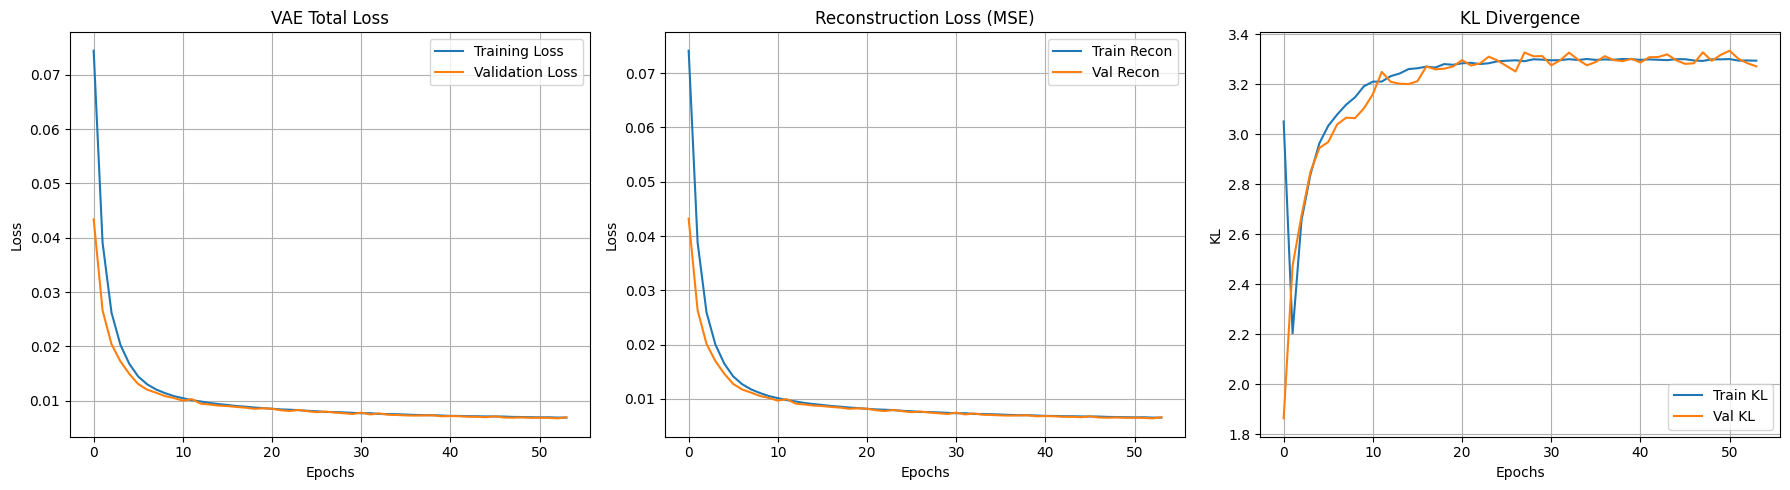

In [14]:
# Plot training and validation loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total loss
axes[0].plot(train_losses, label='Training Loss')
axes[0].plot(val_losses, label='Validation Loss')
axes[0].set_title('VAE Total Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Reconstruction loss
axes[1].plot(train_recon_losses, label='Train Recon')
axes[1].plot(val_recon_losses, label='Val Recon')
axes[1].set_title('Reconstruction Loss (MSE)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# KL divergence
axes[2].plot(train_kl_losses, label='Train KL')
axes[2].plot(val_kl_losses, label='Val KL')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('KL')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


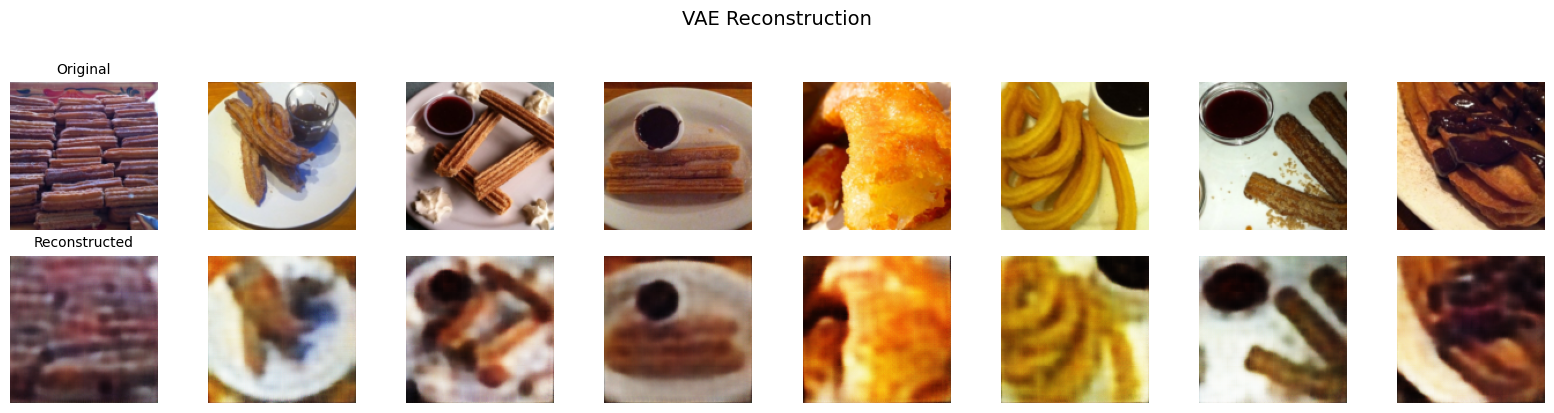

In [15]:
def visualize_reconstructions(model, loader, num_images=8):
    """
    Visualize original images vs. their VAE reconstructions.
    """
    model.eval()
    images, _ = next(iter(loader))
    images = images[:num_images].to(device)

    with torch.no_grad():
        reconstructed, _, _ = model(images)

    images = images.cpu()
    reconstructed = reconstructed.cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
    for i in range(num_images):
        # Original
        axes[0, i].imshow(images[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=10)

        # Reconstructed
        axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).clamp(0, 1))
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=10)

    plt.suptitle('VAE Reconstruction', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


visualize_reconstructions(model, test_loader)


# 8. Test Evaluation

In [16]:
# Evaluate on the test set
test_loss, test_recon, test_kl = validate_epoch(model, test_loader, KL_WEIGHT)
print(
    f"Test Loss: {test_loss:.6f} "
    f"(Recon: {test_recon:.6f}, KL: {test_kl:.2f})"
)


Validation:   0%|          | 0/49 [00:10<?, ?it/s]

Test Loss: 0.006627 (Recon: 0.006297, KL: 3.30)


# 9. Latent Space Sampling (Generative)

One of the key advantages of a VAE over a standard autoencoder is the ability to generate **new** images by sampling from the learned latent distribution.

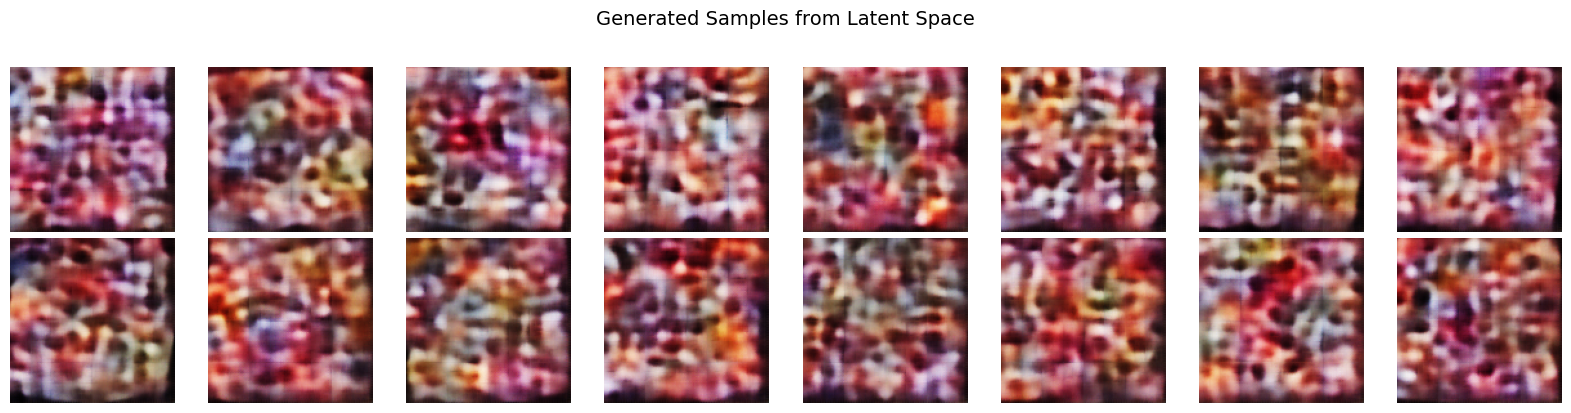

In [17]:
def generate_samples(model, num_samples=16, latent_dim=LATENT_DIM):
    """
    Generate new images by sampling from the prior distribution N(0, I)
    and decoding the samples.
    """
    model.eval()
    with torch.no_grad():
        # Sample z from standard normal distribution
        z = torch.randn(num_samples, latent_dim).to(device)
        generated = model.decode(z)
        generated = generated.cpu()

    # Plot the generated images
    cols = min(8, num_samples)
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    if rows == 1:
        axes = axes[np.newaxis, :]

    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            if idx < num_samples:
                axes[i, j].imshow(generated[idx].permute(1, 2, 0).clamp(0, 1))
            axes[i, j].axis('off')

    plt.suptitle('Generated Samples from Latent Space', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


generate_samples(model, num_samples=16)


# 10. Latent Space Interpolation

Interpolating between two images in latent space to show smooth transitions — a hallmark of well-trained VAEs.

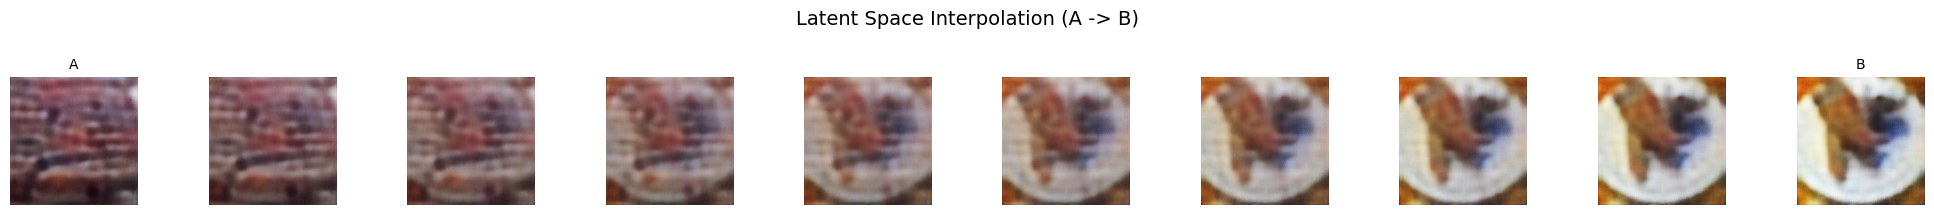

In [18]:
def interpolate_latent(model, loader, num_steps=10):
    """
    Interpolate between two images in latent space and
    decode the intermediate points.
    """
    model.eval()
    images, _ = next(iter(loader))
    img_a = images[0:1].to(device)
    img_b = images[1:2].to(device)

    with torch.no_grad():
        mu_a, _ = model.encode(img_a)
        mu_b, _ = model.encode(img_b)

        # Linear interpolation in latent space
        interpolations = []
        for alpha in np.linspace(0, 1, num_steps):
            z = (1 - alpha) * mu_a + alpha * mu_b
            decoded = model.decode(z)
            interpolations.append(decoded.cpu())

    fig, axes = plt.subplots(1, num_steps, figsize=(num_steps * 2, 2))
    for i, img in enumerate(interpolations):
        axes[i].imshow(img[0].permute(1, 2, 0).clamp(0, 1))
        axes[i].axis('off')
        if i == 0:
            axes[i].set_title('A', fontsize=10)
        elif i == num_steps - 1:
            axes[i].set_title('B', fontsize=10)

    plt.suptitle('Latent Space Interpolation (A -> B)', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()


interpolate_latent(model, test_loader)
